In [1]:
!pip install opencv-python-headless mediapipe torch scikit-learn numpy matplotlib tqdm

In [2]:
import cv2
import mediapipe as mp
import numpy as np
import os
from pathlib import Path
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from collections import Counter

In [14]:

BASE = Path("videos")
SOURCES = ["education-nationale", "elix", "jauvert"]
EXTS = {".webm"}


In [15]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device utilisé :", device)

Device utilisé : mps


In [16]:
infos = {}
tous_les_mots = []

In [6]:
for src in SOURCES:
    d = BASE / src
    if not d.exists():
        print(f"⚠️  dossier introuvable : {d}")
        continue
    vids = [p for p in d.iterdir() if p.suffix.lower() in EXTS]
    mots = [p.stem for p in vids]
    infos[src] = mots
    tous_les_mots += mots
    print(f"{src:22s} : {len(vids)} vidéos")

print("\nTotal vidéos :", len(tous_les_mots))
print("Mots distincts (toutes sources) :", len(set(tous_les_mots)))

education-nationale    : 469 vidéos
elix                   : 100 vidéos
jauvert                : 571 vidéos

Total vidéos : 1140
Mots distincts (toutes sources) : 1094


In [7]:
# Quels mots existent dans plusieurs sources (= plusieurs signeurs) ?
compte = Counter(tous_les_mots)
multi = {m: c for m, c in compte.items() if c > 1 }

print("Mots présents dans plusieurs sources :", len(multi))
print(f"Mots dans plusieurs sources :\n {dict(list(multi.items()))}")


Mots présents dans plusieurs sources : 46
Mots dans plusieurs sources :
 {'formation': 2, 'directeur': 2, 'conseiller': 2, 'concours': 2, 'hôpital': 2, 'critiquer': 2, 'zoo': 2, 'embaucher': 2, 'usine': 2, 'diplôme': 2, 'montagne': 2, 'banque': 2, 'intervenir': 2, 'télévision': 2, 'avocat': 2, 'éducateur': 2, 'exemple': 2, 'dossier': 2, 'baptême': 2, 'accompagner': 2, 'expression du visage': 2, 'infirmière': 2, 'terre': 2, 'homme': 2, 'cinéma': 2, 'informer': 2, 'Marseille': 2, 'école': 2, 'langue': 2, 'soigner': 2, 'médecin': 2, 'mairie': 2, 'charpente': 2, 'ville': 2, 'histoire': 2, 'chance': 2, 'chapeau': 2, 'cousin': 2, 'collège': 2, 'bonjour': 2, 'croissant': 2, 'champignon': 2, 'couscous': 2, 'chaussette': 2, 'chemin': 2, 'clown': 2}


In [8]:
liste_doublon = pd.DataFrame.from_dict(multi, orient='index')


In [9]:
# Aperçu des noms réels (pour voir casse/accents)
print("\nExemples de noms de fichiers (elix) :", infos.get("elix", [])[:15])


Exemples de noms de fichiers (elix) : ['colline', 'colère', 'couronne', 'cravate', 'bobine', 'chauve-souris', 'chance', 'chapeau', 'croix', 'crocodile', 'coquillage', 'cousin', 'collège', 'couverture', 'champ']


In [10]:
print(infos["elix"][:15])
print(infos["education-nationale"][:15])
print(infos["jauvert"][:15])

['colline', 'colère', 'couronne', 'cravate', 'bobine', 'chauve-souris', 'chance', 'chapeau', 'croix', 'crocodile', 'coquillage', 'cousin', 'collège', 'couverture', 'champ']
['Autriche', 'Nîmes', 'conversion', 'formation', 'abdiquer', 'décentralisation', 'théorie', 'Japon', 'message', 'métier', 'bilan', 'hommage', 'Strasbourg', 'Espagne', 'licenciement']
['rembourser', 'fête', 'ma, mes', 'formation', 'tard', 'changer', 'apercevoir', 'fille', 'cuisine', 'bureau', 'signé', 'voisin', 'voler', 'midi', 'directeur']


In [12]:
lignes = []
for src in SOURCES:
    d = BASE / src
    for p in d.iterdir():
        if p.suffix.lower() in EXTS:
            lignes.append({
                "chemin": str(p),
                "mot": p.stem,            # nom du fichier = label
                "source": src,
            })

df = pd.DataFrame(lignes)

# label encodé en entier (nécessaire pour le modèle)
df["mot"] = df["mot"].str.strip()
classes = sorted(df["mot"].unique())
mot2id = {m: i for i, m in enumerate(classes)}
df["label_id"] = df["mot"].map(mot2id)

print("Vidéos :", len(df))
print("Classes :", len(classes))
print(df.head(10))


Vidéos : 1140
Classes : 1094
                                             chemin               mot  \
0          videos/education-nationale/Autriche.webm          Autriche   
1             videos/education-nationale/Nîmes.webm             Nîmes   
2        videos/education-nationale/conversion.webm        conversion   
3         videos/education-nationale/formation.webm         formation   
4          videos/education-nationale/abdiquer.webm          abdiquer   
5  videos/education-nationale/décentralisation.webm  décentralisation   
6           videos/education-nationale/théorie.webm           théorie   
7             videos/education-nationale/Japon.webm             Japon   
8           videos/education-nationale/message.webm           message   
9            videos/education-nationale/métier.webm            métier   

                source  label_id  
0  education-nationale         7  
1  education-nationale        56  
2  education-nationale       329  
3  education-nationale     

In [20]:
mp_holistic = mp.solutions.holistic
mp_face_mesh = mp.solutions.face_mesh   # ← les FACEMESH_* sont ici
# ── Sélection des points ──

# Pose : haut du corps seulement (indices MediaPipe Pose)
# 11/12 épaules, 13/14 coudes, 15/16 poignets, + quelques repères du buste/tête
POSE_IDX = [11, 12, 13, 14, 15, 16, 23, 24]   # épaules, coudes, poignets, hanches (repère torse)

# Visage : on récupère les indices uniques des groupes sourcils + yeux + bouche
def _indices_from_connections(connections):
    pts = set()
    for a, b in connections:
        pts.add(a); pts.add(b)
    return sorted(pts)

FACE_IDX = sorted(set(
    _indices_from_connections(mp_face_mesh.FACEMESH_LIPS) +
    _indices_from_connections(mp_face_mesh.FACEMESH_LEFT_EYEBROW) +
    _indices_from_connections(mp_face_mesh.FACEMESH_RIGHT_EYEBROW) +
    _indices_from_connections(mp_face_mesh.FACEMESH_LEFT_EYE) +
    _indices_from_connections(mp_face_mesh.FACEMESH_RIGHT_EYE)
))
# Tailles (x, y uniquement → 2 coords par point)
N_POSE = len(POSE_IDX)      # 8
N_HAND = 21                 # par main
N_FACE = len(FACE_IDX)      # ~ plusieurs dizaines

In [22]:
N_FEATURES = (N_POSE + N_HAND + N_FACE) * 2
print("Points : pose", N_POSE, "| main x2", N_HAND, "| visage", N_FACE)
print("FEATURES par frame :", N_FEATURES)

def _extract_xy(landmark_list, idx_list, n_expected):
    """Renvoie un vecteur plat (len = n_expected*2) ou des zéros si absent."""
    if landmark_list is None:
        return np.zeros(n_expected * 2, dtype=np.float32)
    lm = landmark_list.landmark
    out = []
    for i in idx_list:
        out.append(lm[i].x)
        out.append(lm[i].y)
    return np.array(out, dtype=np.float32)

Points : pose 8 | main x2 21 | visage 92
FEATURES par frame : 242


In [23]:
def vectoriser_video(chemin):
    """Vidéo → séquence de vecteurs (nb_frames, N_FEATURES)."""
    cap = cv2.VideoCapture(str(chemin))
    sequence = []

    with mp_holistic.Holistic(
        static_image_mode=False,
        model_complexity=1,
        refine_face_landmarks=True,      # meilleurs points yeux/lèvres
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5,
    ) as holistic:
        while cap.isOpened():
            ok, frame = cap.read()
            if not ok:
                break
            # MediaPipe attend du RGB
            image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            res = holistic.process(image)

            pose = _extract_xy(res.pose_landmarks, POSE_IDX, N_POSE)
            lh   = _extract_xy(res.left_hand_landmarks, range(N_HAND), N_HAND)
            rh   = _extract_xy(res.right_hand_landmarks, range(N_HAND), N_HAND)
            face = _extract_xy(res.face_landmarks, FACE_IDX, N_FACE)

            frame_vec = np.concatenate([pose, lh, rh, face])
            sequence.append(frame_vec)

    cap.release()
    return np.array(sequence, dtype=np.float32)

In [24]:
test = df.iloc[0]["chemin"]
seq = vectoriser_video(test)
print("Forme de la séquence :", seq.shape)   # (nb_frames, N_FEATURES)

I0000 00:00:1780410103.466261 7461421 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Max
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1780410103.510577 7498199 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780410103.514049 7498204 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780410103.515613 7498205 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780410103.515714 7498203 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780410103.515720 7498200 inference_feedback_manager.cc:114] Feedback manager requires a

Forme de la séquence : (62, 284)


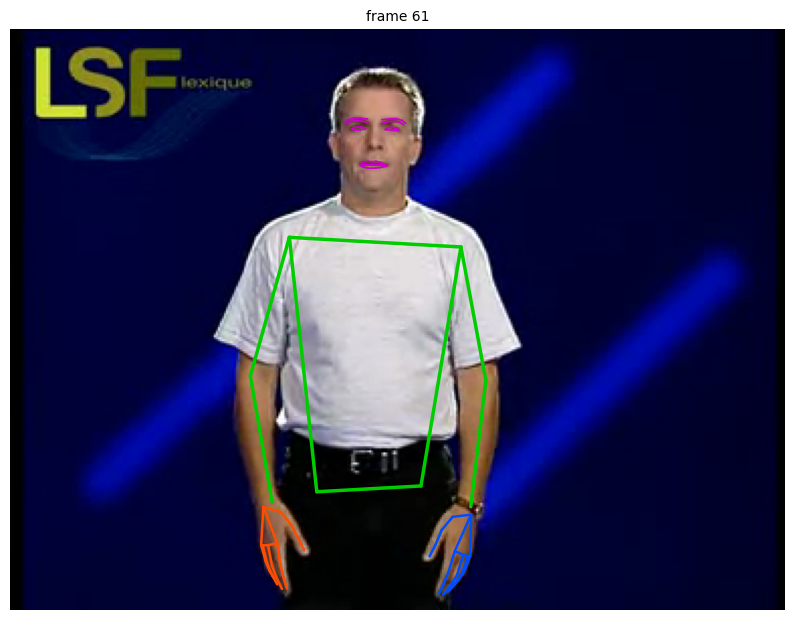

Lecture terminée : 62 frames


In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp
from IPython.display import clear_output, display
import time

mp_holistic = mp.solutions.holistic
mp_face_mesh = mp.solutions.face_mesh

COL_POSE  = (0, 0.8, 0)      # vert
COL_LHAND = (0, 0.3, 1)      # bleu
COL_RHAND = (1, 0.3, 0)      # orange
COL_FACE  = (0.8, 0, 0.8)    # violet

# Connexions du visage limitées à tes groupes (sourcils, yeux, bouche)
FACE_CONN = (
    list(mp_face_mesh.FACEMESH_LIPS) +
    list(mp_face_mesh.FACEMESH_LEFT_EYEBROW) +
    list(mp_face_mesh.FACEMESH_RIGHT_EYEBROW) +
    list(mp_face_mesh.FACEMESH_LEFT_EYE) +
    list(mp_face_mesh.FACEMESH_RIGHT_EYE)
)

# Connexions de la pose limitées au haut du corps (sur tes POSE_IDX)
POSE_CONN_FULL = mp_holistic.POSE_CONNECTIONS
POSE_CONN = [(a, b) for (a, b) in POSE_CONN_FULL if a in POSE_IDX and b in POSE_IDX]

def _draw_lines(ax, landmark_list, connections, color, w, h, lw=1.5):
    """Trace un segment pour chaque connexion (a, b)."""
    if landmark_list is None:
        return
    lm = landmark_list.landmark
    for a, b in connections:
        if a < len(lm) and b < len(lm):
            ax.plot([lm[a].x * w, lm[b].x * w],
                    [lm[a].y * h, lm[b].y * h],
                    color=color, linewidth=lw, solid_capstyle="round")

def lire_video_vecteurs(chemin, pause=0.05, sous_echantillon=1):
    cap = cv2.VideoCapture(str(chemin))
    with mp_holistic.Holistic(
        static_image_mode=False, model_complexity=1,
        refine_face_landmarks=True,
        min_detection_confidence=0.5, min_tracking_confidence=0.5,
    ) as holistic:
        idx = 0
        fig, ax = plt.subplots(figsize=(10, 10))
        while cap.isOpened():
            ok, frame = cap.read()
            if not ok:
                break
            if idx % sous_echantillon == 0:
                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                res = holistic.process(rgb)
                h, w = rgb.shape[:2]

                ax.clear()
                ax.imshow(rgb)
                _draw_lines(ax, res.pose_landmarks, POSE_CONN, COL_POSE, w, h, lw=2.5)
                _draw_lines(ax, res.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, COL_LHAND, w, h, lw=1.8)
                _draw_lines(ax, res.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, COL_RHAND, w, h, lw=1.8)
                _draw_lines(ax, res.face_landmarks, FACE_CONN, COL_FACE, w, h, lw=1.2)
                ax.set_title(f"frame {idx}", fontsize=10)
                ax.axis("off")

                clear_output(wait=True)
                display(fig)
                time.sleep(pause)
            idx += 1
    cap.release()
    plt.close(fig)
    print("Lecture terminée :", idx, "frames")

# ── Lancer ──
chemin = df.iloc[0]["chemin"]
print("Vidéo :", df.iloc[0]["mot"])
lire_video_vecteurs(chemin, pause=0.05)

In [35]:
SEQ_LEN = 48   # longueur cible

# Indices des épaules DANS ton vecteur normalisé.
# Rappel : ton vecteur frame = [pose(8 pts), main_g(21), main_d(21), visage(N)]
# Dans POSE_IDX = [11,12,13,14,15,16,23,24], les épaules 11 et 12 sont
# aux positions 0 et 1 du bloc pose. En (x,y) aplati : épaule G = (0,1), épaule D = (2,3).
EP_G = (0, 1)   # x,y épaule gauche dans le vecteur
EP_D = (2, 3)   # x,y épaule droite dans le vecteur

In [36]:
def recentrer_normaliser(seq):
    """seq : (n_frames, 284) coords brutes x,y → (n_frames, 284) recentré + mis à l'échelle."""
    seq = seq.copy()
    # reshape en (n_frames, n_points, 2) pour traiter x,y par paire
    n_frames = seq.shape[0]
    pts = seq.reshape(n_frames, -1, 2)        # (n_frames, 142, 2)

    # centre = milieu des épaules, par frame
    epaule_g = seq[:, EP_G[0]:EP_G[1]+1]      # (n_frames, 2)
    epaule_d = seq[:, EP_D[0]:EP_D[1]+1]      # (n_frames, 2)
    centre = (epaule_g + epaule_d) / 2.0      # (n_frames, 2)

    # échelle = distance entre épaules, par frame (évite division par 0)
    echelle = np.linalg.norm(epaule_g - epaule_d, axis=1, keepdims=True)  # (n_frames,1)
    echelle = np.where(echelle < 1e-6, 1.0, echelle)

    # recentrer puis mettre à l'échelle
    pts = (pts - centre[:, None, :]) / echelle[:, None, :]
    return pts.reshape(n_frames, -1)          # (n_frames, 284)


def ajouter_deltas(seq):
    """Concatène le mouvement frame-à-frame. (n,284) → (n,568)."""
    deltas = np.zeros_like(seq)
    deltas[1:] = seq[1:] - seq[:-1]           # 1ère frame : delta = 0
    return np.concatenate([seq, deltas], axis=1)


def reechantillonner(seq, longueur=SEQ_LEN):
    """Ré-étale la séquence sur exactement `longueur` frames (interpolation linéaire)."""
    n = seq.shape[0]
    if n == longueur:
        return seq
    if n < 2:   # sécurité : vidéo quasi vide
        return np.repeat(seq, longueur, axis=0)[:longueur]
    # positions cibles réparties sur [0, n-1]
    idx_cible = np.linspace(0, n - 1, longueur)
    idx_bas = np.floor(idx_cible).astype(int)
    idx_haut = np.minimum(idx_bas + 1, n - 1)
    poids = (idx_cible - idx_bas)[:, None]
    return (1 - poids) * seq[idx_bas] + poids * seq[idx_haut]


def preprocesser(seq_brute):
    """Pipeline complet : (n,284) brut → (48, 568) prêt pour le modèle."""
    seq = recentrer_normaliser(seq_brute)     # normalisation positions
    seq = ajouter_deltas(seq)                 # + mouvement → 568
    seq = reechantillonner(seq, SEQ_LEN)      # → 48 frames
    return seq.astype(np.float32)

In [37]:
seq_brute = vectoriser_video(df.iloc[0]["chemin"])   # (62, 284)
seq_prete = preprocesser(seq_brute)
print("Brut :", seq_brute.shape, "→ Prêt :", seq_prete.shape)   # attendu : (48, 568)

I0000 00:00:1780410910.036644 7461421 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Max
W0000 00:00:1780410910.081565 7510258 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780410910.084941 7510255 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780410910.086324 7510258 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780410910.086325 7510257 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780410910.086613 7510255 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling supp

Brut : (62, 284) → Prêt : (48, 568)


In [ ]:
import numpy as np
from pathlib import Path
from tqdm import tqdm

OUT_DIR = Path("dataset_vectorise")
OUT_DIR.mkdir(exist_ok=True)

X = []          # séquences (48, 568)
y = []          # label_id
meta = []       # (mot, source) pour traçabilité
erreurs = []    # vidéos qui ont planté

for row in tqdm(df.itertuples(), total=len(df)):
    try:
        seq_brute = vectoriser_video(row.chemin)
        if seq_brute.shape[0] < 2:          # vidéo vide ou illisible
            erreurs.append((row.chemin, "trop courte"))
            continue
        seq = preprocesser(seq_brute)        # (48, 568)
        X.append(seq)
        y.append(row.label_id)
        meta.append((row.mot, row.source))
    except Exception as e:
        erreurs.append((row.chemin, str(e)))

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int64)

print("X :", X.shape)        # attendu (~1140, 48, 568)
print("y :", y.shape)
print("Erreurs :", len(erreurs))
for e in erreurs[:10]:
    print("  ", e)

# ── Sauvegarde (pour ne JAMAIS recommencer) ──
np.save(OUT_DIR / "X.npy", X)
np.save(OUT_DIR / "y.npy", y)
np.save(OUT_DIR / "meta.npy", np.array(meta, dtype=object), allow_pickle=True)
# le mapping mot <-> id, indispensable pour décoder les prédictions ensuite
import json
with open(OUT_DIR / "mot2id.json", "w", encoding="utf-8") as f:
    json.dump(mot2id, f, ensure_ascii=False, indent=2)

print("✅ Sauvegardé dans", OUT_DIR.resolve())

  0%|          | 0/1140 [00:00<?, ?it/s]I0000 00:00:1780410948.510198 7461421 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Max
W0000 00:00:1780410948.553657 7510907 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780410948.557511 7510908 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780410948.558113 7510912 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780410948.558143 7510906 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780410948.558300 7510905 inference_feedback_manager.cc:114] Feedback manager requires a model with a si